In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

"""
PKLs = []

for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False"""

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


'\nPKLs = []\n\nfor file in os.listdir(DIR):\n    if file.endswith(".pkl") and "merge" not in file:\n        loaded = pickle.load(open(DIR+file, "rb"))\n        loaded =  {\'res\': (None, None, None, loaded[\'res\'][3], None, loaded[\'res\'][5], loaded[\'res\'][6], None, loaded[\'res\'][8]), \'config\':loaded[\'config\']}\n        PKLs.append(loaded)\n        PKL_titles.append(str(file))\nn = len(PKLs)\nplt.rcParams[\'text.usetex\'] = False'

In [6]:
my_dims = range(1, 4)
idx_per_dim = {}
for dim in my_dims:
    idx_per_dim[dim] = [idx for idx in range(n) if PKLs[idx]['config']['dim'] == dim]
temperatures = {}
parameters = {}
critical_temperatures = []
for i, dim in enumerate(my_dims):
    temperatures[dim] = np.array([PKLs[idx]['res'][6] for idx in idx_per_dim[dim]]) 
    parameters[dim] = np.array([PKLs[idx]['res'][3].squeeze(axis=-1) for idx in idx_per_dim[dim]])

In [7]:
def last_zero(x):
    return np.where(x==0.)[0][-1] if np.any(np.where(x==0.)[0]) else None

In [8]:
critical_temperatures = np.zeros(shape=(len(my_dims), 1))
for idxdim, dim in enumerate(my_dims):
    for r in range(len(parameters[dim][0])):
        critical_temperatures[idxdim] = temperatures[dim][r,0][last_zero(parameters[dim][0,r])]

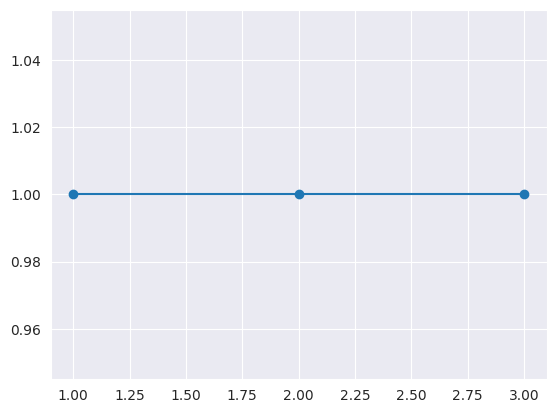

In [9]:
plt.plot(my_dims, critical_temperatures, marker='o', label='Critical Temperature')

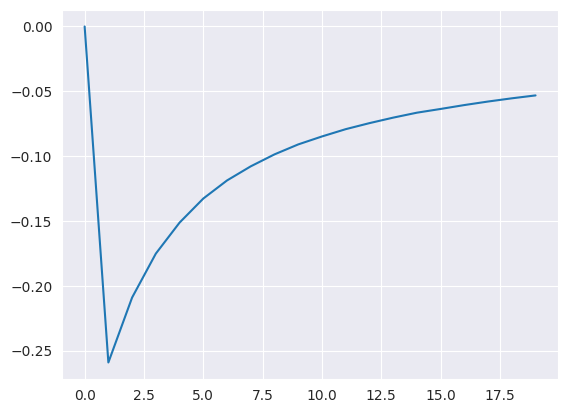

In [21]:
plt.plot(PKLs[0]['res'][-2].T)